# 🌿 Cassava Leaf Disease Classification
## Notebook 05: Hyperparameter Tuning

**ML Coursework Project**

---

### Notebook Objectives
1. Use GridSearchCV for Logistic Regression
2. Use GridSearchCV for SVM
3. Use RandomizedSearchCV for Random Forest
4. Document best parameters found
5. Retrain models with optimal parameters

## 1. Import Libraries

In [1]:
# Core libraries
import os
import numpy as np
import pandas as pd
from pathlib import Path
import json
import pickle
import time

# Machine Learning
from sklearn.metrics import accuracy_score, f1_score, make_scorer
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load Data

In [2]:
# Load configuration
with open('outputs/preprocessing_config.json', 'r') as f:
    config = json.load(f)

# Load features
with open('outputs/extracted_features.pkl', 'rb') as f:
    features = pickle.load(f)

X_train = features['X_train_pca']
X_val = features['X_val_pca']
y_train = features['y_train']
y_val = features['y_val']

CLASSES = config['classes']
NUM_CLASSES = config['num_classes']

print(f"📊 Data Loaded:")
print(f"   - Training samples: {X_train.shape[0]:,}")
print(f"   - Feature dimension: {X_train.shape[1]}")
print(f"   - Classes: {CLASSES}")

📊 Data Loaded:
   - Training samples: 4,524
   - Feature dimension: 3201
   - Classes: ['cbb', 'cbsd', 'cgm', 'cmd', 'healthy']


In [3]:
# Define cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define scoring
scoring = {
    'accuracy': 'accuracy',
    'f1_macro': make_scorer(f1_score, average='macro')
}

print("📊 Cross-Validation Setup:")
print(f"   - Strategy: 5-Fold Stratified")
print(f"   - Scoring: Accuracy, F1-Macro")

📊 Cross-Validation Setup:
   - Strategy: 5-Fold Stratified
   - Scoring: Accuracy, F1-Macro


## 3. Hyperparameter Tuning: Logistic Regression

**Parameters to tune:**
- `C`: Regularization strength (inverse)
- `solver`: Optimization algorithm
- `max_iter`: Maximum iterations

In [4]:
print('=' * 60)
print('Hyperparameter Tuning: Logistic Regression')
print('=' * 60)

param_grid_lr = {
    'C': [0.01, 0.1, 1.0, 10.0, 50.0],
    'solver': ['lbfgs', 'saga'],
    'max_iter': [1000, 2000],
    'class_weight': [None, 'balanced']
}

print('GridSearchCV setup: cv=5, scoring=f1_macro')

Hyperparameter Tuning: Logistic Regression
GridSearchCV setup: cv=5, scoring=f1_macro


In [5]:
lr_base = LogisticRegression(random_state=42)

start_time = time.time()
lr_search = GridSearchCV(
    estimator=lr_base,
    param_grid=param_grid_lr,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)
lr_search.fit(X_train, y_train)
lr_search_time = time.time() - start_time

print(f'Logistic Regression search completed in {lr_search_time:.2f}s')

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Logistic Regression search completed in 3080.47s


In [6]:
print('Logistic Regression - Best Parameters:')
print(lr_search.best_params_)
print(f'Best CV F1-Score: {lr_search.best_score_ * 100:.2f}%')

y_val_pred_lr = lr_search.predict(X_val)
lr_val_acc = accuracy_score(y_val, y_val_pred_lr)
lr_val_f1 = f1_score(y_val, y_val_pred_lr, average='macro')

print(f'Validation Accuracy: {lr_val_acc * 100:.2f}%')
print(f'Validation F1-Score: {lr_val_f1 * 100:.2f}%')

Logistic Regression - Best Parameters:
{'C': 0.01, 'class_weight': 'balanced', 'max_iter': 1000, 'solver': 'lbfgs'}
Best CV F1-Score: 56.90%
Validation Accuracy: 70.85%
Validation F1-Score: 59.26%


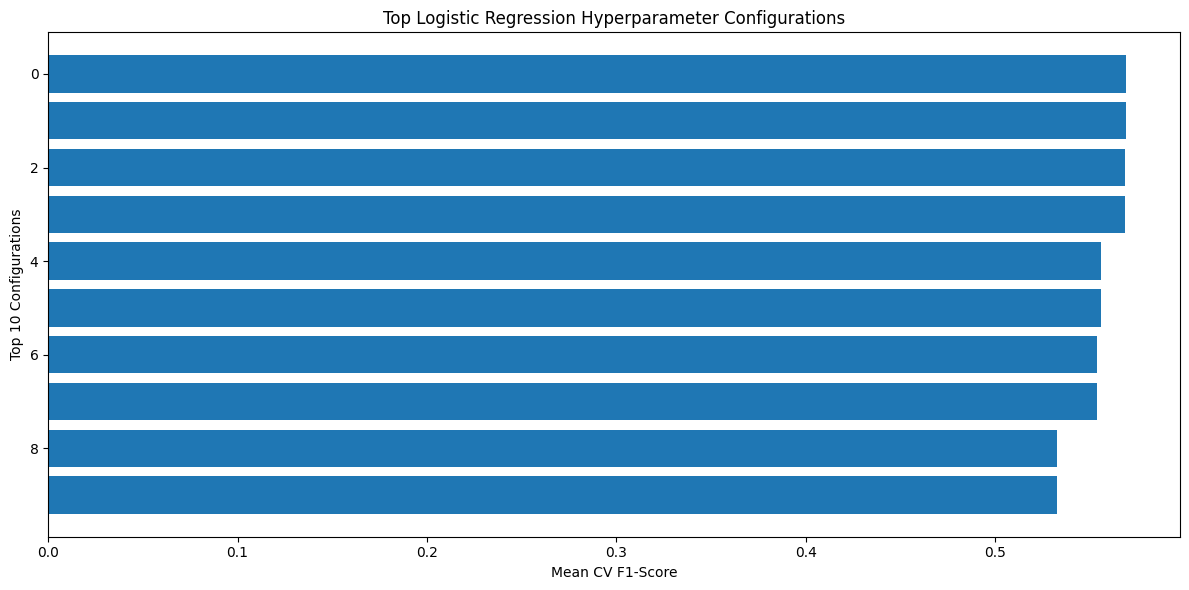

Saved: outputs/logistic_hyperparameter_top10.png


In [7]:
lr_results = pd.DataFrame(lr_search.cv_results_).sort_values('mean_test_score', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(range(len(lr_results)), lr_results['mean_test_score'], color='#1f77b4')
plt.gca().invert_yaxis()
plt.xlabel('Mean CV F1-Score')
plt.ylabel('Top 10 Configurations')
plt.title('Top Logistic Regression Hyperparameter Configurations')
plt.tight_layout()
plt.savefig('outputs/logistic_hyperparameter_top10.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved: outputs/logistic_hyperparameter_top10.png')

## 4. Hyperparameter Tuning: SVM

**Parameters to tune:**
- `C`: Regularization parameter
- `gamma`: Kernel coefficient
- `kernel`: Kernel type

In [8]:
print('=' * 60)
print('Hyperparameter Tuning: SVM (RBF)')
print('=' * 60)

param_grid_svm = {
    'C': [0.1, 1.0, 10.0, 50.0],
    'gamma': ['scale', 0.01, 0.001],
    'kernel': ['rbf'],
    'class_weight': [None, 'balanced']
}

print('GridSearchCV setup: cv=5, scoring=f1_macro')

Hyperparameter Tuning: SVM (RBF)
GridSearchCV setup: cv=5, scoring=f1_macro


In [9]:
svm_base = SVC(probability=True, random_state=42)

start_time = time.time()
svm_search = GridSearchCV(
    estimator=svm_base,
    param_grid=param_grid_svm,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)
svm_search.fit(X_train, y_train)
svm_search_time = time.time() - start_time

print(f'SVM search completed in {svm_search_time:.2f}s')

Fitting 5 folds for each of 24 candidates, totalling 120 fits
SVM search completed in 7415.83s


In [10]:
print('SVM (RBF) - Best Parameters:')
print(svm_search.best_params_)
print(f'Best CV F1-Score: {svm_search.best_score_ * 100:.2f}%')

y_val_pred_svm = svm_search.predict(X_val)
svm_val_acc = accuracy_score(y_val, y_val_pred_svm)
svm_val_f1 = f1_score(y_val, y_val_pred_svm, average='macro')

print(f'Validation Accuracy: {svm_val_acc * 100:.2f}%')
print(f'Validation F1-Score: {svm_val_f1 * 100:.2f}%')

SVM (RBF) - Best Parameters:
{'C': 1.0, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}
Best CV F1-Score: 51.85%
Validation Accuracy: 70.23%
Validation F1-Score: 60.57%


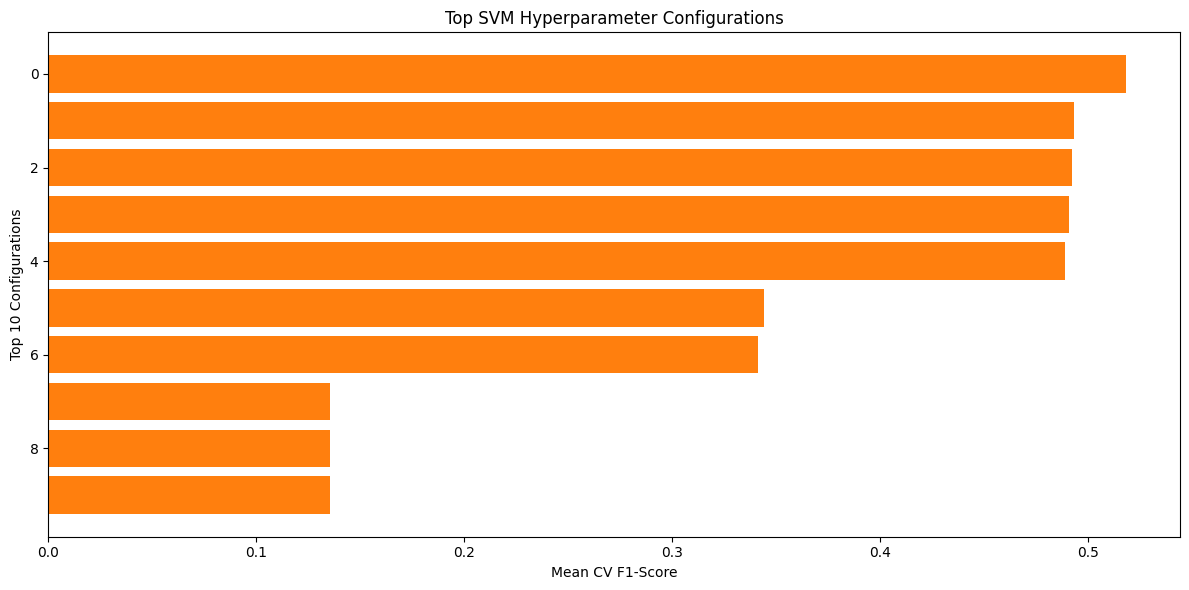

Saved: outputs/svm_hyperparameter_top10.png


In [11]:
svm_results = pd.DataFrame(svm_search.cv_results_).sort_values('mean_test_score', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(range(len(svm_results)), svm_results['mean_test_score'], color='#ff7f0e')
plt.gca().invert_yaxis()
plt.xlabel('Mean CV F1-Score')
plt.ylabel('Top 10 Configurations')
plt.title('Top SVM Hyperparameter Configurations')
plt.tight_layout()
plt.savefig('outputs/svm_hyperparameter_top10.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved: outputs/svm_hyperparameter_top10.png')

In [12]:
print('SVM support vectors per class:')
print(svm_search.best_estimator_.n_support_)

SVM support vectors per class:
[ 373 1110  607 1963  247]


## 5. Hyperparameter Tuning: Random Forest

**Parameters to tune (using RandomizedSearchCV for efficiency):**
- `n_estimators`: Number of trees
- `max_depth`: Maximum depth
- `min_samples_split`: Minimum samples to split
- `min_samples_leaf`: Minimum samples in leaf
- `max_features`: Features at each split

In [13]:
print('=' * 60)
print('Hyperparameter Tuning: Random Forest')
print('=' * 60)

param_dist_rf = {
    'n_estimators': randint(150, 600),
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': randint(2, 12),
    'min_samples_leaf': randint(1, 6),
    'max_features': ['sqrt', 'log2', None],
    'class_weight': [None, 'balanced']
}

print('RandomizedSearchCV setup: n_iter=30, cv=5, scoring=f1_macro')

Hyperparameter Tuning: Random Forest
RandomizedSearchCV setup: n_iter=30, cv=5, scoring=f1_macro


In [14]:
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

start_time = time.time()
rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist_rf,
    n_iter=30,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=True
)
rf_search.fit(X_train, y_train)
rf_search_time = time.time() - start_time

print(f'Random Forest search completed in {rf_search_time:.2f}s')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Random Forest search completed in 9086.76s


In [15]:
print('Random Forest - Best Parameters:')
print(rf_search.best_params_)
print(f'Best CV F1-Score: {rf_search.best_score_ * 100:.2f}%')

y_val_pred_rf = rf_search.predict(X_val)
rf_val_acc = accuracy_score(y_val, y_val_pred_rf)
rf_val_f1 = f1_score(y_val, y_val_pred_rf, average='macro')

print(f'Validation Accuracy: {rf_val_acc * 100:.2f}%')
print(f'Validation F1-Score: {rf_val_f1 * 100:.2f}%')

Random Forest - Best Parameters:
{'class_weight': 'balanced', 'max_depth': 40, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 162}
Best CV F1-Score: 37.01%
Validation Accuracy: 60.42%
Validation F1-Score: 40.78%


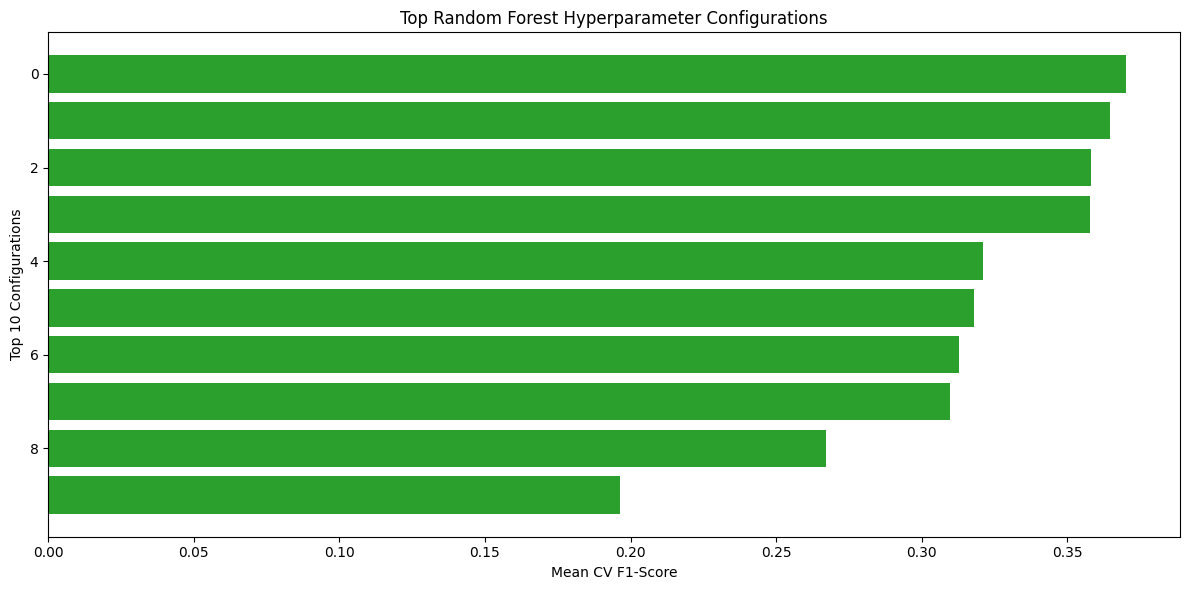

Saved: outputs/random_forest_hyperparameter_top10.png


In [16]:
rf_results = pd.DataFrame(rf_search.cv_results_).sort_values('mean_test_score', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(range(len(rf_results)), rf_results['mean_test_score'], color='#2ca02c')
plt.gca().invert_yaxis()
plt.xlabel('Mean CV F1-Score')
plt.ylabel('Top 10 Configurations')
plt.title('Top Random Forest Hyperparameter Configurations')
plt.tight_layout()
plt.savefig('outputs/random_forest_hyperparameter_top10.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved: outputs/random_forest_hyperparameter_top10.png')

## 6. Summary of Best Parameters

In [17]:
# Save best parameters
best_params = {
    'logistic_regression': lr_search.best_params_,
    'svm': svm_search.best_params_,
    'random_forest': rf_search.best_params_
}

with open('outputs/best_hyperparameters.json', 'w') as f:
    json.dump(best_params, f, indent=2)

print('Best hyperparameters saved to outputs/best_hyperparameters.json')

Best hyperparameters saved to outputs/best_hyperparameters.json


## 7. Retrain Models with Best Parameters

In [18]:
print('=' * 60)
print('Retraining Optimized Models')
print('=' * 60)

lr_optimized = lr_search.best_estimator_
svm_optimized = svm_search.best_estimator_
rf_optimized = rf_search.best_estimator_

lr_optimized.fit(X_train, y_train)
svm_optimized.fit(X_train, y_train)
rf_optimized.fit(X_train, y_train)

tuned_val_metrics = {
    'Logistic Regression': {
        'accuracy': accuracy_score(y_val, lr_optimized.predict(X_val)),
        'f1': f1_score(y_val, lr_optimized.predict(X_val), average='macro')
    },
    'SVM (RBF)': {
        'accuracy': accuracy_score(y_val, svm_optimized.predict(X_val)),
        'f1': f1_score(y_val, svm_optimized.predict(X_val), average='macro')
    },
    'Random Forest': {
        'accuracy': accuracy_score(y_val, rf_optimized.predict(X_val)),
        'f1': f1_score(y_val, rf_optimized.predict(X_val), average='macro')
    }
}

retrain_df = pd.DataFrame([
    {
        'Model': name,
        'Validation Accuracy (%)': values['accuracy'] * 100,
        'Validation F1 (%)': values['f1'] * 100
    }
    for name, values in tuned_val_metrics.items()
]).round(2)

print(retrain_df.to_string(index=False))

Retraining Optimized Models
              Model  Validation Accuracy (%)  Validation F1 (%)
Logistic Regression                    70.85              59.26
          SVM (RBF)                    70.23              60.57
      Random Forest                    60.42              40.78


In [19]:
# Save optimized models
with open('outputs/logistic_regression_optimized.pkl', 'wb') as f:
    pickle.dump(lr_optimized, f)

with open('outputs/svm_optimized.pkl', 'wb') as f:
    pickle.dump(svm_optimized, f)

with open('outputs/random_forest_optimized.pkl', 'wb') as f:
    pickle.dump(rf_optimized, f)

# Save the best overall tuned model for downstream notebooks
best_tuned_model_name = max(tuned_val_metrics, key=lambda name: tuned_val_metrics[name]['f1'])
best_tuned_model = {
    'Logistic Regression': lr_optimized,
    'SVM (RBF)': svm_optimized,
    'Random Forest': rf_optimized
}[best_tuned_model_name]

with open('outputs/best_classifier.pkl', 'wb') as f:
    pickle.dump(best_tuned_model, f)

print('Saved: outputs/logistic_regression_optimized.pkl')
print('Saved: outputs/svm_optimized.pkl')
print('Saved: outputs/random_forest_optimized.pkl')
print(f'Saved: outputs/best_classifier.pkl ({best_tuned_model_name})')

Saved: outputs/logistic_regression_optimized.pkl
Saved: outputs/svm_optimized.pkl
Saved: outputs/random_forest_optimized.pkl
Saved: outputs/best_classifier.pkl (SVM (RBF))


## 8. Performance Comparison: Before vs After Tuning

In [20]:
# Load original training results
with open('outputs/training_results.json', 'r') as f:
    original_results = json.load(f)

comparison_df = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'Baseline Accuracy (%)': original_results['logistic_regression']['val_accuracy'] * 100,
        'Tuned Accuracy (%)': tuned_val_metrics['Logistic Regression']['accuracy'] * 100,
        'Baseline F1 (%)': original_results['logistic_regression']['val_accuracy'] * 100,
        'Tuned F1 (%)': tuned_val_metrics['Logistic Regression']['f1'] * 100
    },
    {
        'Model': 'SVM (RBF)',
        'Baseline Accuracy (%)': original_results['svm']['val_accuracy'] * 100,
        'Tuned Accuracy (%)': tuned_val_metrics['SVM (RBF)']['accuracy'] * 100,
        'Baseline F1 (%)': original_results['svm']['val_accuracy'] * 100,
        'Tuned F1 (%)': tuned_val_metrics['SVM (RBF)']['f1'] * 100
    },
    {
        'Model': 'Random Forest',
        'Baseline Accuracy (%)': original_results['random_forest']['val_accuracy'] * 100,
        'Tuned Accuracy (%)': tuned_val_metrics['Random Forest']['accuracy'] * 100,
        'Baseline F1 (%)': original_results['random_forest']['val_accuracy'] * 100,
        'Tuned F1 (%)': tuned_val_metrics['Random Forest']['f1'] * 100
    }
]).round(2)

comparison_df['Accuracy Improvement (%)'] = (
    comparison_df['Tuned Accuracy (%)'] - comparison_df['Baseline Accuracy (%)']
).round(2)

print(comparison_df.to_string(index=False))

              Model  Baseline Accuracy (%)  Tuned Accuracy (%)  Baseline F1 (%)  Tuned F1 (%)  Accuracy Improvement (%)
Logistic Regression                  68.90               70.85            68.90         59.26                      1.95
          SVM (RBF)                  71.91               70.23            71.91         60.57                     -1.68
      Random Forest                  52.65               60.42            52.65         40.78                      7.77


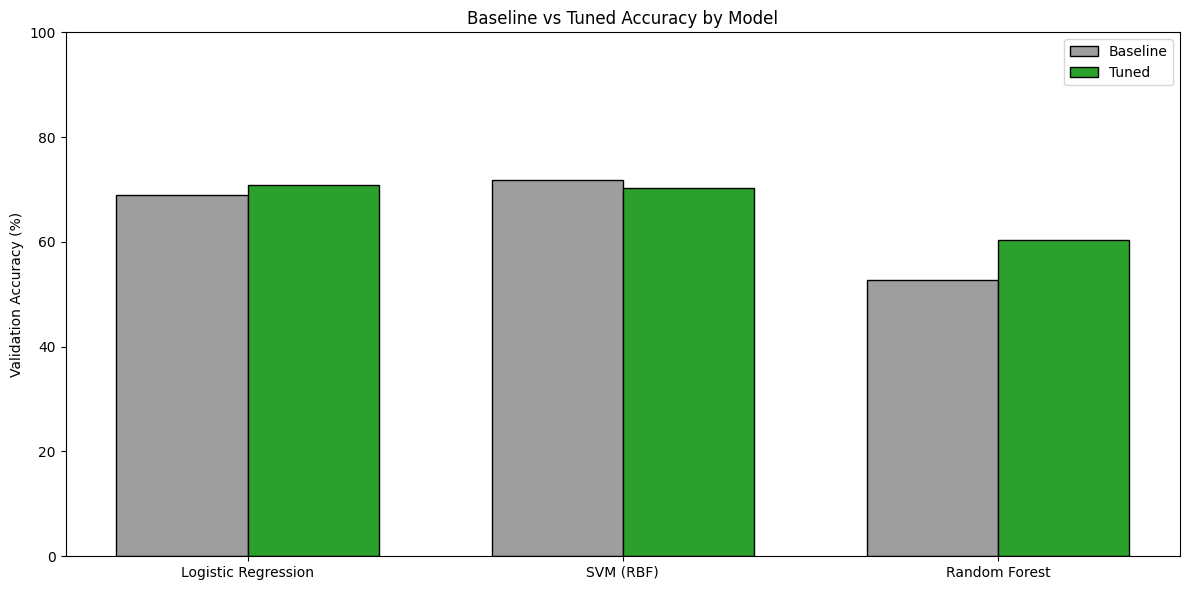

Saved: outputs/tuning_comparison.png


In [21]:
# Visualize comparison
x = np.arange(len(comparison_df))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width / 2, comparison_df['Baseline Accuracy (%)'], width,
       label='Baseline', color='#9e9e9e', edgecolor='black')
ax.bar(x + width / 2, comparison_df['Tuned Accuracy (%)'], width,
       label='Tuned', color='#2ca02c', edgecolor='black')

ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Baseline vs Tuned Accuracy by Model')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'])
ax.set_ylim(0, 100)
ax.legend()

plt.tight_layout()
plt.savefig('outputs/tuning_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved: outputs/tuning_comparison.png')

## 9. Save Tuning Results

In [22]:
# Save tuning results
tuning_results = {
    'logistic_regression': {
        'best_params': lr_search.best_params_,
        'best_cv_score': float(lr_search.best_score_),
        'val_accuracy': float(tuned_val_metrics['Logistic Regression']['accuracy']),
        'val_f1_score': float(tuned_val_metrics['Logistic Regression']['f1']),
        'search_time': float(lr_search_time),
        'search_type': 'GridSearchCV'
    },
    'svm': {
        'best_params': svm_search.best_params_,
        'best_cv_score': float(svm_search.best_score_),
        'val_accuracy': float(tuned_val_metrics['SVM (RBF)']['accuracy']),
        'val_f1_score': float(tuned_val_metrics['SVM (RBF)']['f1']),
        'search_time': float(svm_search_time),
        'search_type': 'GridSearchCV'
    },
    'random_forest': {
        'best_params': rf_search.best_params_,
        'best_cv_score': float(rf_search.best_score_),
        'val_accuracy': float(tuned_val_metrics['Random Forest']['accuracy']),
        'val_f1_score': float(tuned_val_metrics['Random Forest']['f1']),
        'search_time': float(rf_search_time),
        'search_type': 'RandomizedSearchCV'
    }
}

with open('outputs/tuning_results.json', 'w') as f:
    json.dump(tuning_results, f, indent=2)

print('Saved: outputs/tuning_results.json')

Saved: outputs/tuning_results.json


## 10. Summary

In [23]:
print('=' * 60)
print('HYPERPARAMETER TUNING SUMMARY')
print('=' * 60)

for model_name, result in tuning_results.items():
    print(f"{model_name}: CV F1={result['best_cv_score'] * 100:.2f}% | "
          f"Val Acc={result['val_accuracy'] * 100:.2f}% | "
          f"Val F1={result['val_f1_score'] * 100:.2f}% | "
          f"Time={result['search_time']:.2f}s")

best_model = max(tuning_results, key=lambda m: tuning_results[m]['val_f1_score'])
print('-' * 60)
print(f"Best tuned model by validation F1: {best_model}")
print('Saved files:')
print(' - outputs/best_hyperparameters.json')
print(' - outputs/tuning_results.json')
print(' - outputs/logistic_regression_optimized.pkl')
print(' - outputs/svm_optimized.pkl')
print(' - outputs/random_forest_optimized.pkl')
print(' - outputs/best_classifier.pkl')
print(' - outputs/tuning_comparison.png')
print('=' * 60)

HYPERPARAMETER TUNING SUMMARY
logistic_regression: CV F1=56.90% | Val Acc=70.85% | Val F1=59.26% | Time=3080.47s
svm: CV F1=51.85% | Val Acc=70.23% | Val F1=60.57% | Time=7415.83s
random_forest: CV F1=37.01% | Val Acc=60.42% | Val F1=40.78% | Time=9086.76s
------------------------------------------------------------
Best tuned model by validation F1: svm
Saved files:
 - outputs/best_hyperparameters.json
 - outputs/tuning_results.json
 - outputs/logistic_regression_optimized.pkl
 - outputs/svm_optimized.pkl
 - outputs/random_forest_optimized.pkl
 - outputs/best_classifier.pkl
 - outputs/tuning_comparison.png


---
## 📌 Next Steps

Proceed to **Notebook 06: Model Evaluation** to:
1. Generate detailed metrics for all models
2. Create confusion matrices
3. Plot ROC curves
4. Compare models comprehensively
5. Select the best model

---
*End of Notebook 05*